# Project 03: Gibbs Sampling (Random Algorithm)

In [2]:
import math
import random
import numpy as np
import bamnostic as bs
import seqlogo as sl

#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import get_seq
from motif_ops import *

---
## Implement Gibbs Sampler


Gibbs sampling is a MCMC approach to identify enrichments. Here we will implement a method to identify motifs from a set of regions. 

Important considerations:
- We will need to score each sequence with a PWM using the `score_kmer()` or `score_sequence()` functions
    - You will need to investigate into the help documenation and libraries to identify how best to use these functions. 
- These sites are often not strand-specific and so both scores on the negative as well as positive strand should be considered
- To select a random sequence, use `random.randint()` or `numpy.random.randint()`
- To select a new position $m$ (as defined below) use `random.choices()` or `numpy.random.choice()`  

Assumptions: 
- We know $k$ as the length of expected motif
- Each sequence contains the motif



```
GibbsMotifFinder(DNA, k-length)
    random pick of k-length sequences from each line of DNA as Motifs
    for j ← 1 to 10000 or Motifs stops changing
        i ← Random(N) where N is number of DNA entries
        PWM ← PWM constructed from all Motifs except for Motifi
        Motifi ← select position m from PWM-scored k-mers in DNAi in probabilistic fashion from score distribution
    return PFM
```

Probability of chosing position $m = \frac{A_{m}}{\sum_{l}A_{l}}$ for positions $l$ in DNAi


**Note:** I have also added a function to `motif_ops.py` that will calculate the information content of your motifs. This is useful to observe the progression of your Gibbs sampler as well as a measure of convergence. You can use this function as `IC = pfm_ic(pfm)`. You should expect a slow increase of IC until it plateaus such as in the plot below from your lecture slides:

<center><img src='figures/Gibbs_Sampling.png'/ width=600px></center>

---
# Setting up the data

This BAM file contains a subsampled set of aligned ChIP‑seq reads from a p53 immunoprecipitation experiment in human K562 cells treated with the anthracycline drug daunorubicin. The original SRA experiment SRX5865974 (run SRR9090854) reports 31.2 million Illumina NextSeq 500 ChIP‑seq read pairs from K562 wild‑type cells exposed to daunorubicin, using a p53 antibody to pull down p53‑bound chromatin fragments before library preparation and sequencing. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC4366240/)

### What the data represent

- Biological system: human K562 leukemia cells (Homo sapiens) treated with daunorubicin, a DNA‑damaging chemotherapeutic known to stabilize and activate p53. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC6561911/)
- Assay: ChIP‑seq using an antibody against p53, so reads should be enriched around genomic regions where p53 is bound after drug treatment. [pmc.ncbi.nlm.nih](https://pmc.ncbi.nlm.nih.gov/articles/PMC4526040/)
- Sequencing: Illumina NextSeq 500, with the raw run SRR9090854 corresponding to experiment SRX5865974. [github](https://github.com/ncbi/sra-tools/issues/213)
- BAM file: `SRR9090854.subsampled_5pct.bam` is a coordinate‑sorted alignment file containing ~5% of the original mapped reads, typically created by random down‑sampling the full BAM to reduce file size and speed up exploratory analyses while preserving the overall distribution of p53 binding events. [ecseq](https://www.ecseq.com/support/ngs-snippets/how-to-extract-a-list-of-specific-read-IDs-from-a-BAM-file)

### How `bamnostic` is used and what your code does

The `bamnostic` package provides a pure‑Python interface to BAM files that mirrors the `pysam` API, including an `AlignmentFile` class whose iterator yields `AlignedSegment` objects representing individual aligned reads. In your code: [bamnostic.readthedocs](https://bamnostic.readthedocs.io/en/latest/bamnostic.html)

```python
bam_path = "data/SRR9090854.subsampled_5pct.bam"

seqs = [read.seq for read in bs.AlignmentFile(bam_path)]
```

- `bs.AlignmentFile(bam_path)` opens the BAM file as an `AlignmentFile` object in binary read mode (default `'rb'`), reading the BAM header (reference contigs, read groups, etc.) and preparing a streaming interface to all aligned records. [github](https://github.com/betteridiot/bamnostic/blob/master/docs/source/quickstart.rst)
- Iterating over `AlignmentFile` (`for read in bs.AlignmentFile(...)`) returns each aligned read as a `bamnostic.AlignedSegment` object, which exposes properties analogous to SAM fields such as query name, flags, reference name, position, mapping quality, CIGAR string, and the original sequencing **sequence**. [bamnostic.readthedocs](https://bamnostic.readthedocs.io/en/latest/bamnostic.html)
- The `read.seq` attribute is the query (read) sequence string stored in the BAM, corresponding to the full read sequence (including any unaligned bases), as opposed to `query_alignment_sequence`, which would only contain the aligned portion. [bamnostic.readthedocs](https://bamnostic.readthedocs.io/en/latest/bamnostic.html)
- The list comprehension `[read.seq for read in ...]` consumes the entire BAM stream and collects the nucleotide sequences from every subsampled ChIP‑seq read into a Python list `seqs`, which can then be used for downstream tasks such as motif discovery, k‑mer analysis, or quality checks on read content. [ucdavis-bioinformatics-training.github](https://ucdavis-bioinformatics-training.github.io/2022-Feb-Introduction-To-Python-For-Bioinformatics/python/python5)

In summary, your dataset is a 5% random sample of p53‑ChIP‑seq alignments from daunorubicin‑treated K562 cells, and the `bamnostic` code opens the subsampled BAM and extracts the raw read sequences from each aligned fragment into memory as a list.

In [ ]:
# here is our bam file and our sequences loaded in using bamnostic
bam_path = "assignment3/SRR9090854.subsampled_5pct.bam"
seq_file = "assignment3/GCF_000009045.1_ASM904v1_genomic.fna copy"
gff_file = "assignment3/GCF_000009045.1_ASM904v1_genomic.gff copy"

seqs = []
for name, seq in get_fasta(seq_file):
    for gff_entry in get_gff(gff_file):
        if gff_entry.type == 'CDS':
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50)
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

In [12]:
bam = bs.AlignmentFile(bam_path)
next_read = next(bam)
dir(next_read)

['_AlignedSegment__hash_key',
 '_AlignedSegment__qa_end',
 '_AlignedSegment__qa_seq',
 '_AlignedSegment__qa_start',
 '_AlignedSegment__reference_end',
 '_AlignedSegment__reference_length',
 '_AlignedSegment__reference_start',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_bin_mq_nl',
 '_byte_seq',
 '_byte_stream',
 '_cigar',
 '_cigar_builder',
 '_cigartuples',
 '_decode_cigar',
 '_flag_nc',
 '_io',
 '_l_read_name',
 '_n_cigar_op',
 '_qual_builder',
 '_query_alignment_attrs',
 '_range_popper',
 '_raw_qual',
 '_raw_stream',
 '_reference_attrs',
 '_seq_builder',
 '_tag_builder',
 '_tagger',
 '_unpack_data',

---
# Project Start

In [ ]:
# this is our function that will find the binding site motif for p53, but we'll make helper functions for it to so we can break our code up
def GibbsMotifFinder(seqs, k, seed=None):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler

    Args:
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # Use rng to make random samples/selections/numbers
    # Example: randint = rng.integer(1, 10)
    random.seed(seed)
    rng = np.random.default_rng(seed)

    # first we'll want to choose our random motifs from the list for each seq (motifs = choose_motifs(seqs, k, rng))
    motifs = choose_motifs(seqs, k, rng)
    # calculate a pfm with pfm_builder (pfm = pfm_builder(seqs, length))
    pfm = build_pfm(motifs, k)

    # calculate a pwm with the pfm and pwm_builder (new_pwm = build_pwm(pmf))
    pwm = build_pwm(pfm)
    # where this needs to be an iterative process of unknown duration we could pick a stopping point like 10000 (i.e. if we're still going after 10,000 iterations let's stop)
    # could do a for i in range(x):
    for i in range(100001):
        moving_list = []
        # pick a random motif from the motifs (motifs = random_seq(motifs, rng))
        motif, random_int = random_seq(motifs, rng)
        # remove the sequence from both the motif list and the seqs list
        for j in range(len(motifs)):
            if j != random_int:
                moving_list.append(motifs[j])



        # every time we've iterated through say, 100 times:
        if i % 100 == 0 and i > 0:

            # compare the information content of the new pfm to the old pfm (old pfm should be one iteration behind):
            old_ifc = pfm_ic(pfm)
            pfm = build_pfm(moving_list, k)
            pwm = build_pwm(pfm)
            new_ifc = pfm_ic(pfm)

            if math.isclose(new_ifc, old_ifc) == True:
                return pfm


        seq = seqs[random_int]
        # get the reverse_strand of the left out sequence with reverse_complement - use index created above to choose seq
        rev_seq = reverse_complement(seq)
        # get scores of all the motifs of the left out sequence with get_all_scores (use seqs[i] and the reverse strand, using the index from above)
        scores, seq_motifs = get_all_scores(seq, rev_seq, k, pwm)
        # choose the motif with select_motif
        new_motif = select_motif(scores, seq_motifs, i)
        motifs[random_int] = new_motif[0]
        # if the motif came from the reverse strand, replace it in the full seq pool by the random int value
        if seq_motifs.index(new_motif[0]) % 2 == 1:
            seqs[random_int] = rev_seq



    # if we reached the end of the loop, return the pfm
    return pfm


def choose_motifs(seqs, k, rng):
    '''
    Args:
        seqs (str list): a list of sequences
        k (int): the length of the motif to find
        rng: the random number generator to use to get motif positions
    :return: a list of the selected motifs from each position
    '''
    # initialize a motif list
    motif_list = []
    # for seq in seqs
    for seq in seqs:
        # pick a random integer between 0 and len(seq) - len(motif)
        random_int = rng.integers(0, len(seq) - k)
        # append the motif list with seq[int: int + k]
        motif = seq[random_int: random_int + k]
        motif_list.append(motif)
    # return the motif list
    return motif_list


def random_seq(motifs, rng):
    '''

    :param motifs: a list of motifs
    param rng: random number generator to select the sequence to remove
    :return: motif list without the selected sequence
    '''

    # choose a sequence at random (motif list and seq list should line up 1 to 1 so we can do this on the motif list)
    random_int = rng.integers(0, len(motifs) - 1)
    # return motif to remove so that it can be used to recalculate the pwm with calc pwm
    return motifs[random_int], random_int


def get_all_scores(seq, rev_seq, k, pwm):
    '''

    :param seq: sequence to score
    :param rev_seq: reverse compliment of the seq to score
    :param k: motif length
    :param pwm: probability weight matrix to score the sequence against
    :return: a list of scores for each motif in the forward and reverse sequence
    '''

    # initialize a score list for forward and reverse scores
    score_list = []
    seq_motifs = []

    # for each motif in the forward seq:
    for i in range(len(seq) - k + 1):
        f_motif = seq[i: i + k]
        r_motif = rev_seq[i: i + k]


        seq_motifs.append(f_motif)
        seq_motifs.append(r_motif)
        # score the motif with the score_kmer function from motif_ops.py

        f_score = score_kmer(f_motif, pwm)
        r_score = score_kmer(r_motif, pwm)


        # add this score to the list
        score_list.append(f_score)
        score_list.append(r_score)

    # return the score list
    return score_list, seq_motifs


def select_motif(score_list, seq_motifs):
    '''

    :param score_list: a list of pwm based scores for each of the motifs in the forward and reverse seq
    :return: a new motif to be put back in the larger pool
    '''

    # first we need to turn the list of scores into a list of probabilities, so let's initialize that list
    log_scores = []

    # for score in score_list:
    for score in score_list:
        log_score = (2**score)
        log_scores.append(log_score)

    prob_list = []
    for score in log_scores:
        prob = score / sum(log_scores)
        prob_list.append(prob)



    # make a random choice from the seq list with the corresponding prob list as an argument
    return random.choices(seq_motifs, prob_list)
    # return the new motif to put back into the pool


---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

[[27574 27434 27726 27691 27744 27482 27631 27646 27591 27518]
 [22694 22558 22421 22265 22283 22364 22282 22097 21811 22110]
 [22018 22243 21963 22216 22116 22286 22139 22310 22646 22561]
 [27685 27736 27861 27799 27828 27839 27919 27918 27923 27782]]


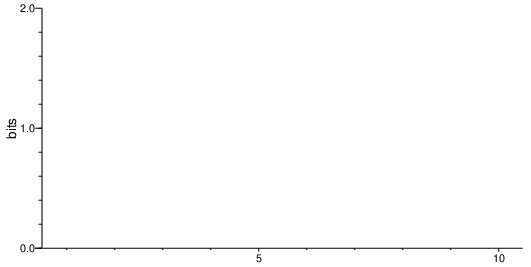

In [10]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(clean_subseqs, 10, seed=10)

# Plot the final pfm that is generated: 
sl.seqlogo(sl.CompletePm(pfm = promoter_pfm.T))